# German Grid Forecasts: Where the Uncertainty Bands Fail

A walkthrough of the ENTSO-E day-ahead forecast calibration audit.

**Article:** https://kwantil.com/papers/german-grid-forecast-calibration/

---

### The question

Every quarter-hour, the German grid is scheduled against a day-ahead forecast of
load, wind and solar. Those forecasts carry uncertainty bands, and decisions should be
made against the bands, not the point estimate.

This asks whether the bands mean what they say. Not *how accurate is the
forecast*, which is the usual question and the wrong one, but **how often did the
truth land inside the stated interval, and were the misses spread evenly or
concentrated where they cost money.**

13 months of DE-LU, with the Netherlands as a comparison zone.


### The Contents

| Section | What happens |
|---|---|
| 1 | Setup and building the panel |
| 2 | Why point error is the wrong metric, shown rather than asserted |
| 3 | Coverage, computed by hand, then checked against the shipped artifact |
| 4 | Where the misses actually are: conditional bias and coverage by hour |
| 5 | Conformal prediction, its feedback controller, and a sweep of the gain |
| 6 | Pricing the gap |
| 7 | What this does not support |

Most sections end with an `assert` naming the published figure. If the paper has
stopped being true, the notebook stops running.

Runtime after the panel exists: roughly two and a half minutes, three quarters
of it in the adaptive-conformal loops of section 5. Every cell that takes more
than about ten seconds says so, with a rough time, in the markdown directly above
it.

## How to run this

**Install.** Python 3.11, then:

```
pip install numpy pandas scipy matplotlib pyarrow entsoe-py jupyter
```

`entsoe-py` is only needed to pull data. Everything downstream reads Parquet, so
a reader working from an existing panel can skip it. The next section prints the
versions actually loaded next to the ones the published run used.

**Data.** Nothing is committed to this repository, derived or otherwise.

| What | Built by | Needed for |
|---|---|---|
| `artifacts/panel.parquet` (~3 MB) | `src/pull_data.py`, `src/assemble.py` | every section |
| `artifacts/coverage_results.parquet` | `src/calibration.py`, then `src/aci.py` | the cross-checks in sections 3 and 5 |
| `artifacts/conditional_bias.parquet` | `src/calibration.py` | the cross-check in section 4 |
| `artifacts/monthly_coverage.parquet` | `src/monthly_coverage.py` | the cross-check in section 5 |
| `artifacts/raw_nl/` (~6 MB) | `src/pull_data_nl.py` | section 6 only |

The pulls need a free ENTSO-E API token in `ENTSOE_API_TOKEN`; `DATA.md` explains
how to request one. Every cell that reads one of these files stops with the file
name and the command that rebuilds it, rather than with a traceback.

The cells below call the three small Parquet files in that table the *shipped*
artifacts. They are shipped by the pipeline, not by the repository: `.gitignore`
excludes every Parquet file, so a fresh clone has none of them and rebuilds all
of them.

**How long.**

- **Cold, no data at all:** 20 to 40 minutes of ENTSO-E pull, rate-limited at
  source and resumable, then roughly two and a half minutes of notebook.
- **Warm, `artifacts/panel.parquet` already on disk:** roughly two and a half
  minutes end to end. Measured on Python 3.11 with pandas 2.2; a slower machine
  scales the three heavy cells below more or less proportionally.

Three cells are nearly all of that, and each says so in the markdown immediately
above it: the adaptive-conformal grid in section 5 (~60 s), the gain sweep in
section 5 (~30 s), and the `nl_monetize.py` subprocess in section 6 (~20 s).
Three others run a single adaptive-conformal loop and take about five seconds.
Nothing downstream of the pull is cached: those cells recompute on every run, and
only the ENTSO-E pull is skipped when its output already exists.

**What works without the expensive steps.** With `artifacts/panel.parquet` and
the three small DE artifacts, sections 1 to 5 run start to finish. That is the
whole calibration argument, the conformal result included. Section 6 prices it,
and it is the only part that needs `artifacts/raw_nl/` and the second subprocess.
With no data at all the notebook stops at the first cell of section 1 and tells
you what to pull.

## 1. Setup

No data ships with this repository. You need a free ENTSO-E API token; `DATA.md`
explains how to request one. Then set `ENTSOE_API_TOKEN`.

In [1]:
from __future__ import annotations

from importlib import metadata
from pathlib import Path
import os
import platform
import re
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Run from notebooks/ or from the analysis root; both work.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

# Plain plots. The article figures are styled; these are for reading numbers.
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})
INK, CLAY, MADDER, GOLD, SLATE = "#1a1815", "#8a4b23", "#8f2620", "#937212", "#2f4d78"

# The four audited series and the two panel columns that define each one.
TARGETS: dict[str, tuple[str, str]] = {
    "load": ("load_fc", "load_act"),
    "solar": ("solar_fc", "solar_act"),
    "wind_on": ("wind_on_fc", "wind_on_act"),
    "wind_off": ("wind_off_fc", "wind_off_act"),
}
LEVELS = (0.80, 0.90, 0.95)
WIN, MIN_OBS, GAMMA = 90, 60, 0.02   # trailing window, min observations, ACI gain


def need(rel: str, how: str) -> Path:
    """Fail with instructions rather than a bare traceback.

    A missing file here is nearly always a missing pull, not a bug, and a reader
    who hits a raw FileNotFoundError has no way to know which of the two it is.
    """
    path = ROOT / rel
    if not path.exists():
        raise SystemExit(
            f"Missing {rel}\n"
            f"  This repository ships no raw data. To build it:\n"
            f"    {how}\n"
            f"  Full guide: DATA.md"
        )
    return path


print("analysis root:", ROOT.name)

analysis root: german-grid-forecast-calibration


### Versions in use

The numbers below are computed, not stored, so the library doing the computing is
part of the result. Rolling windows, quantile interpolation and Parquet round-trips
are implementation rather than specification, and they have moved between releases
before. If a figure here differs from the article, read this table before reading
anything else.

In [2]:
# What the published run used. Not enforced -- a mismatch is information, not an
# error -- but it is the first thing to check when a number below is close to the
# article's and not equal to it.
PUBLISHED_VERSIONS = {
    "python": "3.11.9",
    "numpy": "2.2.6",
    "pandas": "2.2.3",
    "scipy": "1.17.1",
    "matplotlib": "3.10.1",
    "pyarrow": "19.0.1",
    "entsoe-py": "0.8.0",
}


def dist_version(name: str) -> str:
    """Installed version of one distribution, or a readable absence."""
    if name == "python":
        return platform.python_version()
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return "not installed"


print(f"{'package':<12} {'in use':<16} published run")
drift = []
for name, published in PUBLISHED_VERSIONS.items():
    found = dist_version(name)
    if found != published:
        drift.append(name)
    print(f"{name:<12} {found:<16} {published}"
          f"{'' if found == published else '   <-- differs'}")

print(f"\n{platform.platform()}")

if dist_version("entsoe-py") == "not installed":
    print("\nentsoe-py is absent: the ENTSO-E pull in section 1 cannot run, but every")
    print("cell that reads an existing artifact can.")
if drift:
    print(f"\n{len(drift)} of {len(PUBLISHED_VERSIONS)} differ from the published run: "
          f"{', '.join(drift)}")
else:
    print("\nevery version matches the published run")

package      in use           published run
python       3.11.9           3.11.9
numpy        2.2.6            2.2.6
pandas       2.2.3            2.2.3
scipy        1.17.1           1.17.1
matplotlib   3.10.1           3.10.1
pyarrow      19.0.1           19.0.1
entsoe-py    0.8.0            0.8.0

Windows-10-10.0.19045-SP0

every version matches the published run


In [4]:
if not os.environ.get("ENTSOE_API_TOKEN"):
    print("ENTSOE_API_TOKEN is not set.")
    print("The next cell stops with instructions if artifacts/panel.parquet")
    print("is also absent; if the panel is already built, nothing needs it.")
    print("See DATA.md to request a token.")
else:
    print("token set correctly")

token set correctly


### Build the panel

Pull day-ahead forecasts and realised actuals for load, wind onshore, wind
offshore and solar, then align them onto one quarter-hourly panel.

**Slow cell, and the only one that is skipped when its output already exists:
20 to 40 minutes on a cold run, under a second when `artifacts/panel.parquet` is
present.** The pull is rate-limited at source and resumable, so an interrupted
run continues from the chunks already on disk rather than starting over.

**This is the first of only two subprocess calls in the notebook**, and it is
here because it is slow I/O, not because it is where the argument lives.

**On the window.** The published audit covers 2025-07-01 to 2026-07-31. Running
without explicit dates pulls a later window, so your figures will differ from the
article. That is expected, not a bug.

In [5]:
# Three separate commands, not chained: PowerShell 5.1 has no `&&`.
PANEL_BUILD = ("python src/pull_data.py\n"
            "python src/pull_data_nl.py\n"
            "python src/assemble.py")
PANEL = ROOT / "artifacts" / "panel.parquet"

if not PANEL.exists():
    # A missing token is the common case, and a rate-limited HTTP failure forty
    # minutes in is the expensive one. Both end here, with the command to run.
    if not os.environ.get("ENTSOE_API_TOKEN"):
        raise SystemExit(
            "Missing artifacts/panel.parquet, and ENTSOE_API_TOKEN is not set,\n"
            "  so it cannot be built from here. Request a token, export it, then:\n"
            f"    {PANEL_BUILD}\n"
            "  Full guide: DATA.md"
        )
    for step in ("src/pull_data.py", "src/pull_data_nl.py", "src/assemble.py"):
        print("running", step, flush=True)
        result = subprocess.run([sys.executable, step], cwd=ROOT, check=False)
        if result.returncode:
            raise SystemExit(
                f"{step} exited {result.returncode}; artifacts/panel.parquet was "
                "not built.\n"
                "  The pull is resumable: re-running continues from the chunks\n"
                "  already on disk.\n"
                f"    {PANEL_BUILD}\n"
                "  Full guide: DATA.md"
            )

panel = pd.read_parquet(need("artifacts/panel.parquet", PANEL_BUILD))
print(f"panel: {panel.shape[0]:,} rows x {panel.shape[1]} columns")
print(f"index: {panel.index.min()}  ..  {panel.index.max()}  (tz={panel.index.tz})")
print()
print("missing-data audit, % NaN by column:")
missing_pct = panel.isna().mean() * 100
print(missing_pct.round(4).to_string())
panel.head(3)

panel: 38,016 rows x 10 columns
index: 2025-06-30 22:00:00+00:00  ..  2026-07-31 21:45:00+00:00  (tz=UTC)

missing-data audit, % NaN by column:
load_fc                  0.0000
load_act                 0.0000
solar_fc                 0.0105
solar_act                0.0000
wind_on_fc               0.0105
wind_on_act              0.0000
wind_off_fc              0.0000
wind_off_act             0.0000
da_price                 0.0000
da_price_native_15min    0.0000


,load_fc,load_act,solar_fc,solar_act,wind_on_fc,wind_on_act,wind_off_fc,wind_off_act,da_price,da_price_native_15min
2025-06-30 22:00:00+00:00,46443.02,46870.729,0.0,64.350,10890.82,10704.610,2127.78,2242.918,111.28,True
2025-06-30 22:15:00+00:00,45627.72,46192.028,0.0,56.691,11122.57,11065.213,2174.57,2301.331,111.28,False
2025-06-30 22:30:00+00:00,45241.58,45694.663,0.0,54.374,11355.00,11255.180,2224.39,2370.048,111.28,False


Ten columns: a forecast and an actual for each of the four series, the day-ahead
price, and a flag recording whether that price arrived natively at 15-minute
resolution or was forward-filled from an hourly print. The MTU change lands in
October 2025, mid-window, so both regimes are present.

The article's data footnote is two numbers. Check both.

In [6]:
N_ROWS_PUBLISHED = 38_016          # article: "38,016 quarter-hours"
WORST_MISSING_PCT = 0.05           # article: "worst series missingness 0.05%"

assert len(panel) == N_ROWS_PUBLISHED, (
    f"panel has {len(panel):,} rows; the article audits {N_ROWS_PUBLISHED:,} "
    "quarter-hours. A different window was pulled -- see DATA.md."
)
worst = missing_pct.drop("da_price_native_15min", errors="ignore").max()
assert worst <= WORST_MISSING_PCT, (
    f"worst-column missingness is {worst:.4f}%, above the article's stated "
    f"{WORST_MISSING_PCT}% ceiling"
)
print(f"{len(panel):,} quarter-hours; worst column {worst:.4f}% missing "
      f"(article ceiling {WORST_MISSING_PCT}%)")
print(f"day-ahead price native at 15 min for "
      f"{panel.da_price_native_15min.mean():.1%} of rows")

38,016 quarter-hours; worst column 0.0105% missing (article ceiling 0.05%)
day-ahead price native at 15 min for 82.6% of rows


## 2. Point error is the wrong metric

The standard forecast report is an error metric: MAE, RMSE, MAPE. It answers
*how far off on average*.

A scheduling decision does not consume an average. It consumes a **distribution**:
how much reserve to hold, how much to buy in the day-ahead market, how much
exposure to leave to imbalance. That decision needs to know how often the truth
lands outside the band, and by how much.

Compute both, on the same data, and compare what they tell you.

In [7]:
# Derive the forecast/actual pairs from the columns themselves rather than from
# a guessed list of names: a hardcoded list silently drops any series whose
# naming does not match, and a dropped series is an incomplete audit.
pairs: list[tuple[str, str, str]] = []
for fc in [c for c in panel.columns if c.endswith("_fc")]:
    base = fc[:-3]
    act = next((c for c in (f"{base}_act", f"{base}_actual") if c in panel.columns), None)
    if act:
        pairs.append((base, fc, act))

expected_fc = sum(1 for c in panel.columns if c.endswith("_fc"))
assert len(pairs) == expected_fc, (
    f"{expected_fc} forecast columns but only {len(pairs)} paired; "
    "a series would be silently missing from the audit"
)
assert {b for b, _, _ in pairs} == set(TARGETS), (
    f"discovered pairs {sorted(b for b, _, _ in pairs)} do not match TARGETS "
    f"{sorted(TARGETS)}"
)

print("forecast / actual pairs found:")
for base, fc, act in pairs:
    print(f"  {base:10s} {fc:14s} {act}")

rows = []
for base, fc, act in pairs:
    err = (panel[act] - panel[fc]).dropna()
    rows.append({"series": base, "n": len(err),
                 "MAE (MW)": err.abs().mean(),
                 "RMSE (MW)": np.sqrt((err ** 2).mean()),
                 "mean bias (MW)": err.mean()})
errors = pd.DataFrame(rows).set_index("series")
errors.round(1)

forecast / actual pairs found:
  load       load_fc        load_act
  solar      solar_fc       solar_act
  wind_on    wind_on_fc     wind_on_act
  wind_off   wind_off_fc    wind_off_act


,n,MAE (MW),RMSE (MW),mean bias (MW)
series,,,,
load,38016,2098.0,2687.9,-385.4
solar,38012,652.4,1275.6,-56.0
wind_on,38012,1231.7,1769.3,-76.7
wind_off,38016,535.8,742.3,176.1


Sign convention throughout: **error = actual minus forecast**, so a negative bias
means the forecast ran high.

In [8]:
# Article section 1: load carries "an overall mean bias of -385 MW and a mean
# absolute error of 2.1 GW"; offshore wind "+176 MW average under-forecast";
# solar "nearly unbiased on average (-56 MW)".
PUBLISHED_BIAS_MW = {"load": -385.0, "solar": -56.0, "wind_off": 176.0}
PUBLISHED_LOAD_MAE_MW = 2100.0

for series, published in PUBLISHED_BIAS_MW.items():
    got = errors.loc[series, "mean bias (MW)"]
    assert abs(got - published) <= 10.0, (
        f"{series} mean bias is {got:+.1f} MW; the article says {published:+.0f} MW"
    )
    print(f"{series:9s} bias {got:+8.1f} MW   (article {published:+.0f} MW)")

mae = errors.loc["load", "MAE (MW)"]
assert abs(mae - PUBLISHED_LOAD_MAE_MW) <= 100.0, (
    f"load MAE is {mae:.0f} MW; the article says 2.1 GW"
)
print(f"load      MAE  {mae:8.1f} MW   (article 2.1 GW)")

load      bias   -385.4 MW   (article -385 MW)
solar     bias    -56.0 MW   (article -56 MW)
wind_off  bias   +176.1 MW   (article +176 MW)
load      MAE    2098.0 MW   (article 2.1 GW)


Those numbers are fine and they are not the point. **A mean bias near zero is
consistent with being badly wrong every midday and compensating every night.**
Solar's `-56 MW` is exactly that shape. Section 4 is where it shows up.

## 3. Coverage, by hand

An interval promises a containment rate. A 90% band claims the truth lands inside
it 90% of the time. So count.

$$\text{coverage} = \frac{1}{N}\sum_t \mathbb{1}\left[L_t \le e_t \le U_t\right]$$

where $e_t$ is the forecast error at quarter-hour $t$ and $[L_t, U_t]$ is the band
a desk would have quoted for it the day before.

There is no interval published with the forecast, so one has to be constructed,
and the construction is the thing under test. Two habits:

- **Gaussian** — fit mean and standard deviation to the trailing 90 days of
  errors *for that quarter-hour slot*, then take $\mu \pm z\sigma$. This is the
  parametric habit that is the default, due to its simplicity.
- **Rolling split-conformal** — same window, but take the empirical quantiles of
  the errors instead of fitting a Gaussian to them. The textbook
  distribution-free alternative.

Both are fitted per slot, because the 12:15 error distribution has nothing to do
with the 03:15 one, and both are shifted one day, so a band is always quotable
before the outcome it is scored against. Four small functions, and the last one
is the whole of this section: coverage is a tally, so it is written as a tally.

In [11]:
def to_slot_grid(series: pd.Series, tz: str = "Europe/Berlin") -> pd.DataFrame:
    """Reshape a quarter-hourly series to date x quarter-hour slot in local time.

    Local time, not UTC: the effects under audit are solar and human, so they
    track the wall clock rather than the meridian, and a DST shift has to move
    the slot with them.
    """
    local = series.index.tz_convert(tz)
    long = pd.DataFrame({
        "value": series.to_numpy(),
        "date": local.date,
        "slot": local.hour * 4 + local.minute // 15,
    }).dropna()
    return long.pivot_table(index="date", columns="slot", values="value")


def error_frame(frame: pd.DataFrame, fc_col: str, act_col: str,
                tz: str = "Europe/Berlin") -> pd.DataFrame:
    """Forecast errors, actual minus forecast, on the date x slot grid."""
    return to_slot_grid(frame[act_col] - frame[fc_col], tz=tz)


def trailing_bands(err: pd.DataFrame, level: float, method: str,
                   win: int = WIN, min_obs: int = MIN_OBS,
                   ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Construct the band a desk could have quoted, one day ahead of the outcome.

    The ``shift(1)`` is the entire honesty of the exercise: without it the window
    contains the day it is scoring and every method looks calibrated.
    """
    tail = (1.0 - level) / 2.0
    roll = err.rolling(win, min_periods=min_obs)
    if method == "gaussian":
        mu, sd = roll.mean().shift(1), roll.std().shift(1)
        z = float(norm.ppf(1.0 - tail))
        return mu - z * sd, mu + z * sd
    if method == "conformal":
        return roll.quantile(tail).shift(1), roll.quantile(1.0 - tail).shift(1)
    raise ValueError(f"unknown method {method!r}; expected 'gaussian' or 'conformal'")


def count_coverage(err: pd.DataFrame, lo: pd.DataFrame, hi: pd.DataFrame,
                   ) -> tuple[int, int]:
    """Count landings inside the band. Returns (inside, scored).

    Deliberately a count and not an estimator: the claim under test is a
    frequency, and the honest way to check a frequency is to tally it.
    """
    scored = lo.notna() & hi.notna() & err.notna()
    inside = (err >= lo) & (err <= hi) & scored
    return int(inside.to_numpy().sum()), int(scored.to_numpy().sum())

Look at the object before using it. One target, one level, one method.

In [12]:
load_err = error_frame(panel, *TARGETS["load"])
print(f"load errors: {load_err.shape[0]} dates x {load_err.shape[1]} slots "
      f"= {load_err.size:,} cells, {int(load_err.notna().to_numpy().sum()):,} populated")
print(f"dates {load_err.index.min()} .. {load_err.index.max()}")
print("\nfirst 3 dates, first 6 slots (MW, actual minus forecast):")
print(load_err.iloc[:3, :6].round(1).to_string())

lo, hi = trailing_bands(load_err, 0.90, "gaussian")
inside, scored = count_coverage(load_err, lo, hi)
print("\nnominal 90%, gaussian, load")
print(f"  scored quarter-hours : {scored:,}")
print(f"  landed inside        : {inside:,}")
print(f"  landed outside       : {scored - inside:,}")
print(f"  coverage             : {inside / scored:.4f}")
print(f"\nthe first {MIN_OBS} dates are unscored: no band exists yet "
      f"({load_err.shape[0] * load_err.shape[1] - scored:,} cells dropped, "
      f"burn-in plus gaps).")

load errors: 396 dates x 96 slots = 38,016 cells, 38,012 populated
dates 2025-07-01 .. 2026-07-31

first 3 dates, first 6 slots (MW, actual minus forecast):
slot             0       1       2       3       4       5
date                                                      
2025-07-01   427.7   564.3   453.1   173.3   754.6   773.0
2025-07-02  2117.4  2183.3  2186.2  1984.9  1603.2  2143.9
2025-07-03  2964.6  2486.7  2099.5  1541.5  1818.5  2270.9

nominal 90%, gaussian, load
  scored quarter-hours : 32,252
  landed inside        : 27,337
  landed outside       : 4,915
  coverage             : 0.8476

the first 60 dates are unscored: no band exists yet (5,764 cells dropped, burn-in plus gaps).


84.76%, not 90%. One in six of the quarter-hours a desk had called a
one-in-ten event.

Now the whole grid: four targets, three nominal levels, two constructions.

In [13]:
grid_rows = []
for target, (fc, act) in TARGETS.items():
    err = error_frame(panel, fc, act)
    for level in LEVELS:
        for method in ("gaussian", "conformal"):
            lo, hi = trailing_bands(err, level, method)
            inside, scored = count_coverage(err, lo, hi)
            width = (hi - lo)[lo.notna() & hi.notna() & err.notna()].mean().mean()
            grid_rows.append({
                "target": target, "level": level, "method": method,
                "inside": inside, "scored": scored,
                "coverage": inside / scored, "shortfall": inside / scored - level,
                "mean_width_mw": float(width),
            })

by_hand = pd.DataFrame(grid_rows)
by_hand.round(4)

,target,level,method,inside,scored,coverage,shortfall,mean_width_mw
0,load,0.80,gaussian,23654,32252,0.7334,-0.0666,5879.6408
1,load,0.80,conformal,23453,32252,0.7272,-0.0728,5803.0025
2,load,0.90,gaussian,27337,32252,0.8476,-0.0524,7546.4372
3,load,0.90,conformal,26932,32252,0.8350,-0.0650,7381.7898
4,load,0.95,gaussian,29417,32252,0.9121,-0.0379,8992.1346
5,load,0.95,conformal,28815,32252,0.8934,-0.0566,8626.6702
6,solar,0.80,gaussian,25590,32248,0.7935,-0.0065,1932.3668
7,solar,0.80,conformal,23603,32248,0.7319,-0.0681,1796.2317
8,solar,0.90,gaussian,27809,32248,0.8623,-0.0377,2480.1660
9,solar,0.90,conformal,26816,32248,0.8316,-0.0684,2330.3006


### The cross-check

The same quantities are shipped in `artifacts/coverage_results.parquet`, written
by `src/calibration.py`. That script's logic lives inside its `main()`, so it
cannot be imported and called; it has been reimplemented above in three
functions. The reimplementation is worth exactly as much as this next cell says
it is.

In [14]:
COVERAGE_PARQUET = need(
    "artifacts/coverage_results.parquet",
    "python src/calibration.py   (then: python src/aci.py)",
)
shipped = pd.read_parquet(COVERAGE_PARQUET)
print(f"shipped artifact: {shipped.shape[0]} rows, methods "
      f"{sorted(shipped.method.unique())}")

check = by_hand.merge(
    shipped[shipped.method.isin(["gaussian", "conformal"])],
    on=["target", "level", "method"], suffixes=("_inline", "_shipped"),
)
assert len(check) == 24, f"expected 24 gaussian/conformal rows, matched {len(check)}"

cov_gap = (check.coverage_inline - check.coverage_shipped).abs().max()
width_gap = (check.mean_width_mw_inline - check.mean_width_mw_shipped).abs().max()
assert cov_gap < 1e-12, f"inline coverage differs from src/calibration.py by {cov_gap:.3e}"
assert width_gap < 1e-9, f"inline width differs from src/calibration.py by {width_gap:.3e}"

print(f"\n24 of 24 cells agree with src/calibration.py")
print(f"  largest coverage difference : {cov_gap:.2e}")
print(f"  largest width difference    : {width_gap:.2e}")
print("\nThe count above is the shipped number. Nothing is hidden in the script.")

shipped artifact: 36 rows, methods ['aci', 'conformal', 'gaussian']

24 of 24 cells agree with src/calibration.py
  largest coverage difference : 0.00e+00
  largest width difference    : 0.00e+00

The count above is the shipped number. Nothing is hidden in the script.


Now the article's own table. Section 2 of the paper prints the nominal-90% cells:

| Nominal 90% band | Gaussian | Rolling conformal |
|---|---|---|
| Load | 84.8% | 83.5% |
| Solar | 86.2% | 83.2% |
| Wind onshore | 88.9% | 86.2% |
| Wind offshore | 88.3% | 86.6% |

In [15]:
# Article section 2, the nominal-90% table.
PUBLISHED_90 = {
    ("load", "gaussian"): 0.848, ("load", "conformal"): 0.835,
    ("solar", "gaussian"): 0.862, ("solar", "conformal"): 0.832,
    ("wind_on", "gaussian"): 0.889, ("wind_on", "conformal"): 0.862,
    ("wind_off", "gaussian"): 0.883, ("wind_off", "conformal"): 0.866,
}
at90 = by_hand[by_hand.level == 0.90].set_index(["target", "method"])

for key, published in PUBLISHED_90.items():
    got = at90.loc[key, "coverage"]
    assert abs(got - published) <= 0.001, (
        f"{key[0]} / {key[1]} covers {got:.4f}; the article publishes {published:.3f}"
    )
    print(f"{key[0]:9s} {key[1]:10s} {got:.4f}  (article {published:.3f})")

# Article, of that table: "Every cell is below nominal ... real coverage of 83-89%."
cells90 = by_hand[by_hand.level == 0.90]
assert (cells90.shortfall < 0).all(), (
    "the article's claim that every cell of the nominal-90% table falls below "
    "nominal no longer holds"
)
assert 0.83 <= cells90.coverage.min() and cells90.coverage.max() <= 0.89 + 5e-4, (
    f"nominal-90% coverage spans {cells90.coverage.min():.4f}-"
    f"{cells90.coverage.max():.4f}; the article says 83-89%"
)
closest = cells90.loc[cells90.shortfall.idxmax()]
print(f"\nall 8 cells of the 90% table below nominal, spanning "
      f"{cells90.coverage.min():.1%}-{cells90.coverage.max():.1%} "
      "(article: 83-89%)")
print(f"the closest is {closest.target}/{closest.method}, short by "
      f"{abs(closest.shortfall):.4f}")

# At nominal 80% and 95% the picture is not uniform, and the article does not
# claim it is: three of the eight gaussian cells there sit above nominal.
above = by_hand[(by_hand.level != 0.90) & (by_hand.shortfall > 0)]
print(f"\nfor contrast, {len(above)} of {len(by_hand) - len(cells90)} cells at "
      f"nominal 80%/95% land above nominal: "
      f"{', '.join(f'{r.target}/{r.method}@{r.level:.0%}' for r in above.itertuples())}")

# The distribution-free method is the worse of the two, everywhere.
paired = by_hand.pivot_table(index=["target", "level"], columns="method",
                             values="coverage")
assert (paired.conformal < paired.gaussian).all(), (
    "rolling conformal is no longer below the gaussian in every cell"
)
print(f"\nrolling conformal covers less than the gaussian in all "
      f"{len(paired)} target-level cells, by "
      f"{(paired.gaussian - paired.conformal).min():.4f} to "
      f"{(paired.gaussian - paired.conformal).max():.4f}")

load      gaussian   0.8476  (article 0.848)
load      conformal  0.8350  (article 0.835)
solar     gaussian   0.8623  (article 0.862)
solar     conformal  0.8316  (article 0.832)
wind_on   gaussian   0.8893  (article 0.889)
wind_on   conformal  0.8623  (article 0.862)
wind_off  gaussian   0.8832  (article 0.883)
wind_off  conformal  0.8663  (article 0.866)

all 8 cells of the 90% table below nominal, spanning 83.2%-88.9% (article: 83-89%)
the closest is wind_on/gaussian, short by 0.0107

for contrast, 2 of 16 cells at nominal 80%/95% land above nominal: wind_on/gaussian@80%, wind_off/gaussian@80%

rolling conformal covers less than the gaussian in all 12 target-level cells, by 0.0062 to 0.0616


**Read the gap between nominal and empirical.** An interval that promises 90% and
delivers 83% is not a conservative interval, it is a wrong one, and every
downstream reserve decision inherits the error.

Note also that conformal is *worse* than the Gaussian in every one of the twelve
cells. The distribution-free method is not rescuing anything here, which is the
first hint of section 5.

## 4. Where the misses are

Marginal coverage is an average over all hours. Forecast error is not distributed
evenly over the day, and neither is the cost of being wrong.

Start with the point forecast, because the mechanism is clearest there. Group the
errors by hour of day and take the mean.

In [16]:
# On the raw quarter-hours, not the date x slot grid of section 3. The autumn
# DST fall-back puts two quarter-hours into one (date, slot) cell, and the grid
# averages them; a bias tally should count both. It is a handful of rows in
# 38,016 and it moves the answer by ~5 MW -- small, but it is the difference
# between agreeing with the shipped artifact and nearly agreeing with it.
bias_rows = []
for target, (fc, act) in TARGETS.items():
    err = (panel[act] - panel[fc]).dropna()
    hourly_err = err.groupby(err.index.tz_convert("Europe/Berlin").hour)
    stat = pd.DataFrame({"bias_mw": hourly_err.mean(), "n": hourly_err.size()})
    stat.index.name = "hour"
    bias_rows.append(stat.assign(target=target).reset_index())

bias = pd.concat(bias_rows, ignore_index=True)
wide_bias = bias.pivot(index="hour", columns="target", values="bias_mw")
print("conditional bias, MW, actual minus forecast:")
print(wide_bias.round(0).to_string())

conditional bias, MW, actual minus forecast:
target    load  solar  wind_off  wind_on
hour                                    
0        342.0   12.0     238.0     18.0
1        268.0   11.0     232.0    -19.0
2         94.0   10.0     209.0   -137.0
3        108.0   10.0     204.0   -193.0
4        124.0   10.0     190.0   -176.0
5        121.0   -1.0     185.0    -32.0
6        476.0  -11.0     166.0    172.0
7         82.0  -74.0     137.0    101.0
8       -298.0 -143.0     179.0   -128.0
9       -919.0  -98.0     158.0   -335.0
10     -1526.0  -31.0     144.0   -338.0
11     -1814.0  -94.0     111.0   -255.0
12     -1967.0 -282.0      82.0   -210.0
13     -1953.0 -421.0      72.0   -311.0
14     -1804.0 -364.0      84.0   -431.0
15     -1366.0 -216.0     141.0   -328.0
16      -955.0   -8.0     181.0    -86.0
17      -291.0  145.0     212.0    194.0
18        79.0  112.0     221.0    311.0
19       290.0   40.0     191.0    221.0
20       285.0    1.0     184.0     32.0
21       408

In [17]:
SHIPPED_BIAS = need("artifacts/conditional_bias.parquet", "python src/calibration.py")
shipped_bias = pd.read_parquet(SHIPPED_BIAS)
merged = bias.merge(shipped_bias, on=["target", "hour"], suffixes=("_inline", "_shipped"))
assert len(merged) == 96, f"expected 4 targets x 24 hours, matched {len(merged)}"
bias_gap = (merged.bias_mw_inline - merged.bias_mw_shipped).abs().max()
assert bias_gap < 1e-9, f"inline bias differs from src/calibration.py by {bias_gap:.3e} MW"
print(f"96 of 96 hourly biases agree with src/calibration.py "
      f"(largest difference {bias_gap:.2e} MW)")

# Article section 1: load "overshoots reality by ~1.9-2.0 GW at midday (hours
# 11-14)"; offshore wind is "worst overnight (hours 22-01, ~+240 MW)".
midday = wide_bias.loc[11:14, "load"]
assert (midday < -1700).all() and (midday > -2100).all(), (
    f"load midday bias is {midday.round(0).to_dict()}; the article says "
    "~-1.9 to -2.0 GW across hours 11-14"
)
overnight = wide_bias.loc[[22, 23, 0, 1], "wind_off"].mean()
assert abs(overnight - 240.0) <= 25.0, (
    f"offshore overnight bias is {overnight:+.0f} MW; the article says ~+240 MW"
)
print(f"load, hours 11-14 : {midday.min():+.0f} to {midday.max():+.0f} MW "
      "(article ~-1.9 to -2.0 GW)")
print(f"wind_off, 22-01   : {overnight:+.0f} MW (article ~+240 MW)")
print(f"\nsolar's daily mean bias is {bias[bias.target == 'solar'].bias_mw.mean():+.0f} MW "
      f"but its hourly extremes run "
      f"{wide_bias['solar'].min():+.0f} to {wide_bias['solar'].max():+.0f} MW.")

96 of 96 hourly biases agree with src/calibration.py (largest difference 0.00e+00 MW)
load, hours 11-14 : -1967 to -1804 MW (article ~-1.9 to -2.0 GW)
wind_off, 22-01   : +242 MW (article ~+240 MW)

solar's daily mean bias is -56 MW but its hourly extremes run -421 to +145 MW.


The plot below is the mechanism, not the table restated: the load line is a
single deep trough centred on solar noon, which is what behind-the-meter
generation eroding metered demand looks like from the outside. Two gigawatts of
demand that is forecast and does not arrive, every day, at the same hours.

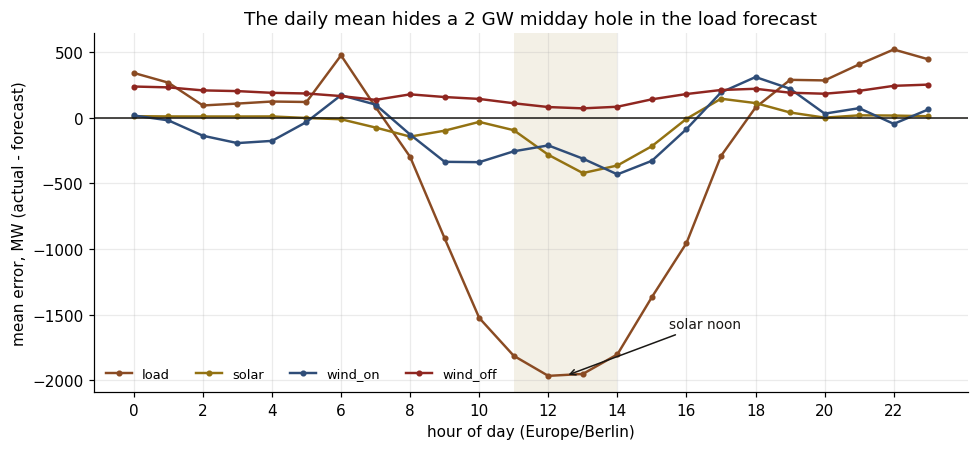

In [18]:
fig, ax = plt.subplots()
for target, colour in zip(TARGETS, (CLAY, GOLD, SLATE, MADDER)):
    ax.plot(wide_bias.index, wide_bias[target], marker="o", ms=3, lw=1.6,
            color=colour, label=target)
ax.axhline(0, color=INK, lw=1)
ax.axvspan(11, 14, color=GOLD, alpha=0.10, lw=0)
ax.annotate("solar noon", xy=(12.5, wide_bias.loc[12, "load"]), xytext=(15.5, -1600),
            fontsize=9, color=INK, arrowprops={"arrowstyle": "->", "color": INK})
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour of day (Europe/Berlin)")
ax.set_ylabel("mean error, MW (actual - forecast)")
ax.set_title("The daily mean hides a 2 GW midday hole in the load forecast")
ax.legend(frameon=False, fontsize=8.5, ncol=4)
plt.tight_layout()
plt.show()

### The same count, split by hour

Bias is the first moment. Coverage is the claim actually being made. Split the
identical tally from section 3 by hour of day: same bands, same landings, one
extra `groupby`.

In [19]:
def coverage_by_hour(err: pd.DataFrame, lo: pd.DataFrame, hi: pd.DataFrame,
                     ) -> pd.DataFrame:
    """count_coverage, split by hour of day.

    The marginal number is what a desk is quoted. This is the number it lives
    with, and the two are only equal if the misses are spread evenly, which is
    the assumption this whole section exists to test.
    """
    scored = lo.notna() & hi.notna() & err.notna()
    inside = (err >= lo) & (err <= hi) & scored
    hour = pd.Index(err.columns // 4, name="hour")
    n = scored.T.groupby(hour).sum().sum(axis=1)
    k = inside.T.groupby(hour).sum().sum(axis=1)
    return pd.DataFrame({"inside": k, "scored": n, "coverage": k / n})


hourly: dict[tuple[str, str], pd.DataFrame] = {}
for target in TARGETS:
    err = error_frame(panel, *TARGETS[target])
    for method in ("gaussian", "conformal"):
        lo, hi = trailing_bands(err, 0.90, method)
        hourly[(target, method)] = coverage_by_hour(err, lo, hi)

solar_conf = hourly[("solar", "conformal")]
print("solar, rolling conformal, nominal 90%, by hour:")
print(solar_conf.assign(coverage=solar_conf.coverage.round(4)).to_string())

# The hour-wise counts must re-add to the marginal count: an arithmetic identity,
# and a guard against the groupby quietly dropping a slot.
for key, frame in hourly.items():
    marginal = by_hand[(by_hand.target == key[0]) & (by_hand.method == key[1])
                       & (by_hand.level == 0.90)].iloc[0]
    assert int(frame.inside.sum()) == int(marginal.inside), key
    assert int(frame.scored.sum()) == int(marginal.scored), key
print("\nhourly counts re-add to the marginal counts of section 3 for all 8 cells")

solar, rolling conformal, nominal 90%, by hour:
      inside  scored  coverage
hour                          
0       1161    1340    0.8664
1       1174    1344    0.8735
2       1179    1340    0.8799
3       1168    1344    0.8690
4       1140    1344    0.8482
5       1078    1344    0.8021
6       1086    1344    0.8080
7       1057    1344    0.7865
8       1093    1344    0.8132
9       1140    1344    0.8482
10      1170    1344    0.8705
11      1174    1344    0.8735
12      1158    1344    0.8616
13      1147    1344    0.8534
14      1115    1344    0.8296
15      1097    1344    0.8162
16      1044    1344    0.7768
17      1024    1344    0.7619
18      1065    1344    0.7924
19      1084    1344    0.8065
20      1074    1344    0.7991
21      1069    1344    0.7954
22      1139    1344    0.8475
23      1180    1344    0.8780

hourly counts re-add to the marginal counts of section 3 for all 8 cells


In [20]:
price_by_hour = panel.groupby(panel.index.tz_convert("Europe/Berlin").hour).da_price.mean()

worst_hours = solar_conf.coverage.nsmallest(4).index
mean_price = price_by_hour.mean()
print(f"solar conformal 90%: marginal {solar_conf.inside.sum() / solar_conf.scored.sum():.4f}, "
      f"worst hour {solar_conf.coverage.min():.4f} at h{solar_conf.coverage.idxmin()}, "
      f"best hour {solar_conf.coverage.max():.4f} at h{solar_conf.coverage.idxmax()}")
print(f"the four worst-covered hours are {sorted(worst_hours.tolist())}, "
      f"mean day-ahead price EUR {price_by_hour.loc[worst_hours].mean():.1f}/MWh "
      f"against EUR {mean_price:.1f}/MWh across the day")

assert price_by_hour.loc[worst_hours].mean() > mean_price, (
    "the article's claim that the misses concentrate in expensive hours no "
    "longer holds: the four worst-covered hours are no longer above the "
    "day's mean day-ahead price"
)
assert solar_conf.coverage.min() < 0.80, (
    f"solar's worst hour covers {solar_conf.coverage.min():.4f}; the article "
    "describes a nominal-90% band falling below 80% in the evening ramp"
)

solar conformal 90%: marginal 0.8316, worst hour 0.7619 at h17, best hour 0.8799 at h2
the four worst-covered hours are [7, 16, 17, 18], mean day-ahead price EUR 106.7/MWh against EUR 94.2/MWh across the day


This is the finding, and it is why the plot below carries two axes. Coverage
collapses in the two ramps — around 07:00 and again from 16:00 to 21:00 — and
those are the hours the day-ahead price is high, because the ramps are when
dispatchable plant has to cover a solar fleet that is arriving or leaving. The
band fails hardest in the hours when a MWh of error is worth the most. Midnight,
where the band is comfortably calibrated, is also the cheapest hour of the day.

The marginal number, 83.2%, is an average over a day in which the price of being
wrong varies by a factor of three.

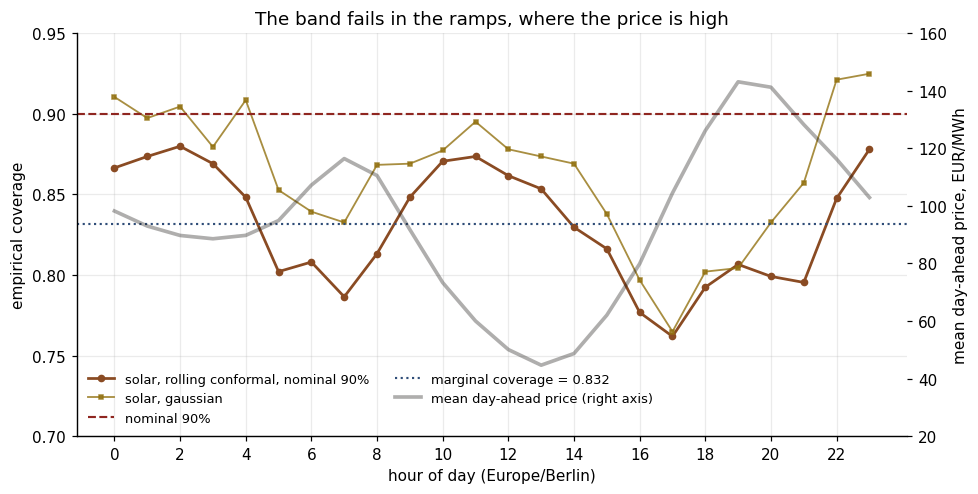

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(solar_conf.index, solar_conf.coverage, marker="o", ms=4, lw=1.8,
        color=CLAY, label="solar, rolling conformal, nominal 90%")
ax.plot(hourly[("solar", "gaussian")].index, hourly[("solar", "gaussian")].coverage,
        marker="s", ms=3, lw=1.2, color=GOLD, alpha=0.8, label="solar, gaussian")
ax.axhline(0.90, color=MADDER, ls="--", lw=1.4, label="nominal 90%")
marginal = solar_conf.inside.sum() / solar_conf.scored.sum()
ax.axhline(marginal, color=SLATE, ls=":", lw=1.4,
           label=f"marginal coverage = {marginal:.3f}")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour of day (Europe/Berlin)")
ax.set_ylabel("empirical coverage")
ax.set_ylim(0.70, 0.95)

ax2 = ax.twinx()
price_line, = ax2.plot(price_by_hour.index, price_by_hour.values, color=INK,
                       lw=2.4, alpha=0.35, label="mean day-ahead price (right axis)")
ax2.set_ylabel("mean day-ahead price, EUR/MWh")
ax2.set_ylim(20, 160)
ax2.grid(False)

ax.set_title("The band fails in the ramps, where the price is high")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [price_line], labels + [price_line.get_label()],
          frameon=False, fontsize=8.5, loc="lower left", ncol=2)
plt.tight_layout()
plt.show()

## 5. Conformal prediction does not rescue this on its own

Adaptive conformal inference (Gibbs & Candès, 2021) is usually presented as
distribution-free insurance against miscalibration. It is a feedback controller
on the miscoverage rate: after each outcome it nudges its own working level,

$$\alpha_{t+1} = \alpha_t + \gamma\,(\alpha - \mathbb{1}[\text{miss}_t])$$

and re-quotes the empirical quantiles at the updated $\alpha_{t+1}$. A miss
widens the next interval; a hit narrows it, slightly. The gain $\gamma$ sets how
hard it pushes.

This has to be a loop. The state at day $t$ depends on whether day $t-1$ was a
miss, which depends on the band the controller had chosen by then. Write it out.

In [22]:
def aci_bands(err: pd.DataFrame, level: float, gamma: float = GAMMA,
              win: int = WIN, min_obs: int = MIN_OBS,
              ) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Adaptive conformal inference, one day at a time. Returns (lo, hi, alpha_t).

    Written as an explicit loop rather than vectorised because the working level
    is a *state*, and a reader who cannot see the state update cannot tell this
    apart from the rolling-quantile method it is built on. The alpha track is
    returned for the same reason: it is the thing that moves.
    """
    values = err.to_numpy()
    n_dates, n_slots = values.shape
    alpha = 1.0 - level
    alpha_t = np.full(n_slots, alpha)          # one controller per quarter-hour slot
    lo = np.full(values.shape, np.nan)
    hi = np.full(values.shape, np.nan)
    track = np.full(values.shape, np.nan)

    for t in range(min_obs, n_dates):
        start = max(0, t - win)
        for s in range(n_slots):
            window = values[start:t, s]
            window = window[~np.isnan(window)]
            outcome = values[t, s]
            if len(window) < min_obs or np.isnan(outcome):
                continue
            # Clipped so a long run of hits cannot drive the level negative.
            working = float(np.clip(alpha_t[s], 0.001, 0.45))
            band_lo = float(np.quantile(window, working / 2.0))
            band_hi = float(np.quantile(window, 1.0 - working / 2.0))
            lo[t, s], hi[t, s], track[t, s] = band_lo, band_hi, working
            missed = 0.0 if band_lo <= outcome <= band_hi else 1.0
            alpha_t[s] = alpha_t[s] + gamma * (alpha - missed)

    def frame(arr: np.ndarray) -> pd.DataFrame:
        return pd.DataFrame(arr, index=err.index, columns=err.columns)

    return frame(lo), frame(hi), frame(track)

### First, prove it is the same method with the feedback switched off

With $\gamma = 0$ the update term vanishes, $\alpha_t$ stays at $\alpha$ forever,
and the controller degenerates into the rolling split-conformal band of section 3.
If it does not reproduce that band's tally *exactly*, the loop above is wrong and
nothing after this cell is worth reading.

In [23]:
solar_err = error_frame(panel, *TARGETS["solar"])

conf_lo, conf_hi = trailing_bands(solar_err, 0.90, "conformal")
zero_lo, zero_hi, zero_track = aci_bands(solar_err, 0.90, gamma=0.0)

conf_counts = count_coverage(solar_err, conf_lo, conf_hi)
zero_counts = count_coverage(solar_err, zero_lo, zero_hi)

assert conf_counts == zero_counts, (
    f"gamma=0 gives {zero_counts} but rolling conformal gives {conf_counts}; "
    "the controller loop is not a superset of the static method"
)
held = zero_track.to_numpy()
assert np.allclose(held[~np.isnan(held)], 0.10), "alpha_t moved with the gain set to zero"
print(f"rolling conformal  : {conf_counts[0]:,} inside of {conf_counts[1]:,}")
print(f"ACI with gamma=0   : {zero_counts[0]:,} inside of {zero_counts[1]:,}")
print("identical. the loop is the static method plus a controller.")

rolling conformal  : 26,816 inside of 32,248
ACI with gamma=0   : 26,816 inside of 32,248
identical. the loop is the static method plus a controller.


### Now switch the controller on

The shipped gain is $\gamma = 0.02$. Run all four targets at all three nominal
levels and check against `artifacts/coverage_results.parquet`, which `src/aci.py`
wrote — the second cross-check, and the same argument as the first: the script is
a reference, not an oracle.

**Slow cell: about 60 seconds** -- twelve adaptive-conformal loops, four targets
by three levels, each a day-by-day pass over the panel. It is not skipped and
nothing is cached; it recomputes on every run. The per-target progress line is
there so a stalled run is distinguishable from a slow one.

In [24]:
aci_rows = []
for target, (fc, act) in TARGETS.items():
    err = error_frame(panel, fc, act)
    for level in LEVELS:
        lo, hi, track = aci_bands(err, level, gamma=GAMMA)
        inside, scored = count_coverage(err, lo, hi)
        valid = lo.notna() & hi.notna() & err.notna()
        aci_rows.append({
            "target": target, "level": level, "method": "aci",
            "inside": inside, "scored": scored, "coverage": inside / scored,
            "mean_width_mw": float((hi - lo)[valid].mean().mean()),
            "mean_alpha": float(track[valid].mean().mean()),
        })
    print(f"{target} done", flush=True)

aci_inline = pd.DataFrame(aci_rows)
aci_inline.round(4)

load done
solar done
wind_on done
wind_off done


,target,level,method,inside,scored,coverage,mean_width_mw,mean_alpha
0,load,0.80,aci,25624,32252,0.7945,6803.5223,0.1388
1,load,0.90,aci,28894,32252,0.8959,8819.2597,0.0513
2,load,0.95,aci,30421,32252,0.9432,10530.0244,0.0106
3,solar,0.80,aci,25562,32248,0.7927,2097.5366,0.1836
4,solar,0.90,aci,28713,32248,0.8904,2808.4537,0.0832
5,solar,0.95,aci,30007,32248,0.9305,3409.8726,0.0331
6,wind_on,0.80,aci,25760,32248,0.7988,4218.2412,0.1679
7,wind_on,0.90,aci,28911,32248,0.8965,6125.1415,0.0682
8,wind_on,0.95,aci,30502,32248,0.9459,8537.1718,0.0229
9,wind_off,0.80,aci,25653,32252,0.7954,1764.4307,0.1683


In [22]:
if "aci" not in set(shipped.method):
    raise SystemExit(
        "artifacts/coverage_results.parquet has no method='aci' rows.\n"
        "  src/calibration.py writes the file; src/aci.py appends to it, and has\n"
        "  not been run against this copy:\n"
        "    python src/aci.py\n"
        "  Full guide: DATA.md"
    )

aci_check = aci_inline.merge(
    shipped[shipped.method == "aci"], on=["target", "level", "method"],
    suffixes=("_inline", "_shipped"),
)
assert len(aci_check) == 12, f"expected 12 aci rows, matched {len(aci_check)}"
aci_gap = (aci_check.coverage_inline - aci_check.coverage_shipped).abs().max()
assert aci_gap < 1e-12, f"inline ACI differs from src/aci.py by {aci_gap:.3e}"
print(f"12 of 12 ACI cells agree with src/aci.py (largest difference {aci_gap:.2e})")

# Article section 3: adaptive conformal delivers 79.3-79.9% at nominal 80%,
# 89.0-89.7% at 90%, 93.1-94.6% at 95%.
PUBLISHED_ACI_RANGES = {0.80: (0.793, 0.799), 0.90: (0.890, 0.897), 0.95: (0.931, 0.946)}
for level, (low, high) in PUBLISHED_ACI_RANGES.items():
    got = aci_inline[aci_inline.level == level].coverage
    assert low - 0.001 <= got.min() and got.max() <= high + 0.001, (
        f"ACI at nominal {level:.0%} spans {got.min():.4f}-{got.max():.4f}; "
        f"the article publishes {low:.1%}-{high:.1%}"
    )
    print(f"nominal {level:.0%}: {got.min():.4f}-{got.max():.4f} "
          f"(article {low:.3f}-{high:.3f})")

12 of 12 ACI cells agree with src/aci.py (largest difference 0.00e+00)
nominal 80%: 0.7927-0.7988 (article 0.793-0.799)
nominal 90%: 0.8904-0.8965 (article 0.890-0.897)
nominal 95%: 0.9305-0.9459 (article 0.931-0.946)


### The width the article puts a price on

> *"adaptive load intervals at 90% average 8.8 GW against the Gaussian's 7.5 GW —
> wider, because 7.5 GW was never actually a 90% band."*

In [23]:
gauss_w = by_hand[(by_hand.target == "load") & (by_hand.level == 0.90)
                  & (by_hand.method == "gaussian")].mean_width_mw.iloc[0]
aci_w = aci_inline[(aci_inline.target == "load")
                   & (aci_inline.level == 0.90)].mean_width_mw.iloc[0]

assert abs(gauss_w / 1000 - 7.5) <= 0.1, f"gaussian load width {gauss_w:.0f} MW, article 7.5 GW"
assert abs(aci_w / 1000 - 8.8) <= 0.1, f"adaptive load width {aci_w:.0f} MW, article 8.8 GW"
print(f"load, nominal 90%: gaussian {gauss_w/1000:.2f} GW covering "
      f"{at90.loc[('load', 'gaussian'), 'coverage']:.3f}")
print(f"                   adaptive {aci_w/1000:.2f} GW covering "
      f"{aci_inline.set_index(['target','level']).loc[('load', 0.90), 'coverage']:.3f}")
print(f"\n{aci_w/gauss_w - 1:.1%} wider, and that is the honest width. Calibration")
print("does not make uncertainty bigger; it stops you understating it.")

load, nominal 90%: gaussian 7.55 GW covering 0.848
                   adaptive 8.82 GW covering 0.896

16.9% wider, and that is the honest width. Calibration
does not make uncertainty bigger; it stops you understating it.


### Sweep the gain and watch the verdict move

Everything above uses $\gamma = 0.02$ because that is what the pipeline ships.
Nothing in the method fixes that value, so it is a modelling decision, and a
modelling decision should be visible.

Sweep it. The data does not change, the window does not change, the target does
not change. Only the controller gain moves, from off to aggressive.

**Slow cell: about 30 seconds** -- six more adaptive-conformal loops, solar only.
Not skipped and not cached; it recomputes on every run.

In [24]:
GAMMA_SWEEP = (0.0, 0.005, 0.01, 0.02, 0.05, 0.10)

sweep_rows = []
sweep_hourly: dict[float, pd.DataFrame] = {}
for gamma in GAMMA_SWEEP:
    lo, hi, track = aci_bands(solar_err, 0.90, gamma=gamma)
    inside, scored = count_coverage(solar_err, lo, hi)
    per_hour = coverage_by_hour(solar_err, lo, hi)
    sweep_hourly[gamma] = per_hour
    valid = lo.notna() & hi.notna() & solar_err.notna()
    sweep_rows.append({
        "gamma": gamma,
        "marginal coverage": inside / scored,
        "worst hour": per_hour.coverage.min(),
        "worst hour idx": int(per_hour.coverage.idxmin()),
        "spread across hours": per_hour.coverage.max() - per_hour.coverage.min(),
        "mean width MW": float((hi - lo)[valid].mean().mean()),
    })
    print(f"gamma={gamma:<6} done", flush=True)

sweep = pd.DataFrame(sweep_rows)
sweep.round(4)

gamma=0.0    done


gamma=0.005  done


gamma=0.01   done


gamma=0.02   done


gamma=0.05   done


gamma=0.1    done


,gamma,marginal coverage,worst hour,worst hour idx,spread across hours,mean width MW
0,0.000,0.8316,0.7619,17,0.1179,2330.3006
1,0.005,0.8675,0.8490,5,0.0394,2608.5042
2,0.010,0.8818,0.8653,5,0.0283,2734.2828
3,0.020,0.8904,0.8743,5,0.0246,2808.4537
4,0.050,0.8942,0.8780,17,0.0250,2844.4256
5,0.100,0.8957,0.8810,5,0.0238,2896.3216


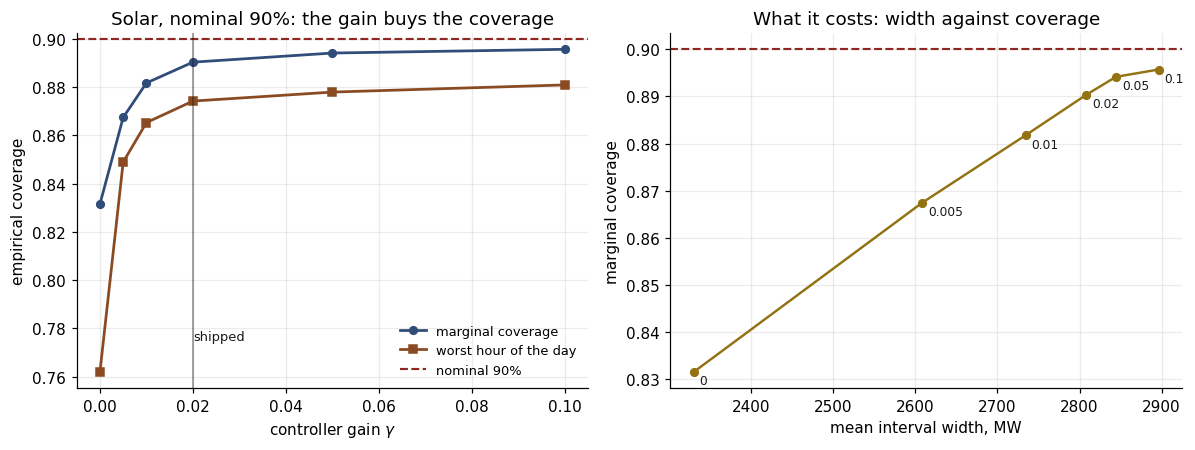

In [25]:
fig, (ax, axw) = plt.subplots(1, 2, figsize=(11, 4.2))

ax.plot(sweep.gamma, sweep["marginal coverage"], marker="o", ms=5, lw=1.8,
        color=SLATE, label="marginal coverage")
ax.plot(sweep.gamma, sweep["worst hour"], marker="s", ms=5, lw=1.8,
        color=CLAY, label="worst hour of the day")
ax.axhline(0.90, color=MADDER, ls="--", lw=1.4, label="nominal 90%")
ax.axvline(GAMMA, color=INK, lw=1.0, alpha=0.5)
ax.annotate("shipped", xy=(GAMMA, 0.775), fontsize=8.5, color=INK)
ax.set_xlabel(r"controller gain $\gamma$")
ax.set_ylabel("empirical coverage")
ax.set_title("Solar, nominal 90%: the gain buys the coverage")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")

axw.plot(sweep["mean width MW"], sweep["marginal coverage"], marker="o", ms=5,
         lw=1.6, color=GOLD)
for _, row in sweep.iterrows():
    axw.annotate(f"{row.gamma:g}", xy=(row["mean width MW"], row["marginal coverage"]),
                 xytext=(4, -8), textcoords="offset points", fontsize=8, color=INK)
axw.axhline(0.90, color=MADDER, ls="--", lw=1.4)
axw.set_xlabel("mean interval width, MW")
axw.set_ylabel("marginal coverage")
axw.set_title("What it costs: width against coverage")

plt.tight_layout()
plt.show()

In [26]:
off, shipped_gain = sweep.iloc[0], sweep[sweep.gamma == GAMMA].iloc[0]
assert off["marginal coverage"] < 0.84 < shipped_gain["marginal coverage"], (
    "the gain sweep no longer moves solar's coverage across the 84% line"
)
assert off["spread across hours"] > 0.10 and shipped_gain["spread across hours"] < 0.04, (
    "the controller no longer collapses the spread of coverage across hours: "
    f"{off['spread across hours']:.4f} with the gain off, "
    f"{shipped_gain['spread across hours']:.4f} at the shipped gain"
)
print(f"gain off (gamma=0)   : marginal {off['marginal coverage']:.4f}, "
      f"worst hour {off['worst hour']:.4f}, "
      f"spread {off['spread across hours']:.4f}, "
      f"width {off['mean width MW']:.0f} MW")
print(f"shipped (gamma={GAMMA}) : marginal {shipped_gain['marginal coverage']:.4f}, "
      f"worst hour {shipped_gain['worst hour']:.4f}, "
      f"spread {shipped_gain['spread across hours']:.4f}, "
      f"width {shipped_gain['mean width MW']:.0f} MW")
print(f"\nThe controller buys {shipped_gain['marginal coverage'] - off['marginal coverage']:+.3f} "
      f"of coverage for {shipped_gain['mean width MW'] / off['mean width MW'] - 1:+.1%} of width.")

gain off (gamma=0)   : marginal 0.8316, worst hour 0.7619, spread 0.1179, width 2330 MW
shipped (gamma=0.02) : marginal 0.8904, worst hour 0.8743, spread 0.0246, width 2808 MW

The controller buys +0.059 of coverage for +20.5% of width.


Two things to take from the sweep, and only the first is the good news.

**It works, and it works per hour.** Because a separate controller runs on each
quarter-hour slot, the adaptation is conditional by construction: the worst hour
climbs with the marginal number rather than being left behind, and the spread of
coverage across the day narrows. That is a real result and it is stronger than
the naive reading of adaptive conformal, which only promises the average.

**And the gain is a free parameter that moves the answer.** At $\gamma = 0$ this
is a method that undercovers by seven points. At $\gamma = 0.02$ it is a method
that hits its target. Nothing in the theory picked 0.02; the pipeline did. Any
verdict quoted from this method is a joint statement about the data and about a
number somebody chose.

**A correction to the article's own summary.** The abstract says adaptive
conformal methods here "hold marginal coverage and still miss where it counts,
because the guarantee is an average over all hours and the cost is not". The
first half of that is right and the diagnosis is right, but the phrase *where it
counts* has to be read as the regime, not the hour. Measured, the shipped
implementation runs a **separate controller per quarter-hour slot**, so hour of
day is conditioned on by construction and the spread of coverage across the day
collapses from 11.8 points to 2.5. What survives is the regime failure below and
the residual euro concentration in section 6. The looser reading of that sentence
does not survive the measurement, which is why the measurement is in this
notebook.

### Where it still breaks: the regime, not the hour

The controller reacts to misses, so it is always a step behind a distribution
that is moving. Split the same tally by month instead of by hour.

In [27]:
def coverage_by_month(err: pd.DataFrame, lo: pd.DataFrame, hi: pd.DataFrame,
                      ) -> pd.DataFrame:
    """count_coverage, split by calendar month.

    Hour-of-day asks whether the misses cluster within a day. Month asks whether
    the error distribution the window is learning from is still the one being
    scored, which is the exchangeability assumption conformal rests on.
    """
    scored = lo.notna() & hi.notna() & err.notna()
    inside = (err >= lo) & (err <= hi) & scored
    month = pd.PeriodIndex(pd.DatetimeIndex(err.index), freq="M").astype(str)
    n = scored.groupby(month).sum().sum(axis=1)
    k = inside.groupby(month).sum().sum(axis=1)
    out = pd.DataFrame({"inside": k, "scored": n, "coverage": k / n})
    # The burn-in months have no band at all; a month with nothing scored is not
    # a month with zero coverage.
    return out[out.scored > 0]


LEVEL_80 = 0.80
monthly = {}
for method in ("gaussian", "conformal"):
    lo, hi = trailing_bands(solar_err, LEVEL_80, method)
    monthly[method] = coverage_by_month(solar_err, lo, hi)
lo, hi, _ = aci_bands(solar_err, LEVEL_80, gamma=GAMMA)
monthly["aci"] = coverage_by_month(solar_err, lo, hi)

solar_monthly = pd.DataFrame({m: f.coverage for m, f in monthly.items()})
solar_monthly["n"] = monthly["gaussian"].scored
print("solar, nominal 80%, coverage by month:")
print(solar_monthly.round(4).to_string())

solar, nominal 80%, coverage by month:
         gaussian  conformal     aci     n
date                                      
2025-08    0.8750     0.8229  0.8177   192
2025-09    0.9139     0.8660  0.8684  2880
2025-10    0.8890     0.8546  0.8250  2972
2025-11    0.9476     0.8587  0.8208  2880
2025-12    0.9647     0.8216  0.7920  2976
2026-01    0.8757     0.8152  0.7715  2976
2026-02    0.7604     0.7132  0.7403  2688
2026-03    0.6124     0.5488  0.6517  2972
2026-04    0.6330     0.5559  0.7438  2880
2026-05    0.6374     0.5837  0.7913  2976
2026-06    0.6122     0.6108  0.8205  2880
2026-07    0.8720     0.8138  0.8898  2976


In [28]:
SHIPPED_MONTHLY = need("artifacts/monthly_coverage.parquet", "python src/monthly_coverage.py")
shipped_monthly = pd.read_parquet(SHIPPED_MONTHLY)
ref = shipped_monthly[(shipped_monthly.target == "solar")
                      & (shipped_monthly.level == LEVEL_80)].set_index("month")

common = solar_monthly.index.intersection(ref.index)
assert len(common) >= 12, f"only {len(common)} months line up with the artifact"
for method in ("gaussian", "conformal", "aci"):
    gap = (solar_monthly.loc[common, method] - ref.loc[common, method]).abs().max()
    # The artifact stores these rounded to four places, so 5e-5 is exact agreement.
    assert gap <= 5e-5, f"inline monthly {method} differs from the artifact by {gap:.2e}"
print(f"{len(common)} months x 3 methods agree with src/monthly_coverage.py "
      "to the artifact's stored precision")

# Article section 2: "solar's nominal-80% band covered only 56-63% through
# spring 2026."
spring = [m for m in solar_monthly.index if m.startswith(("2026-03", "2026-04", "2026-05"))]
assert spring, "no spring-2026 months in this window; a different period was pulled"
trough = solar_monthly.loc[spring, ["gaussian", "conformal"]]
assert 0.50 <= trough.to_numpy().min() and trough.to_numpy().max() <= 0.66, (
    f"spring 2026 solar 80% coverage spans "
    f"{trough.to_numpy().min():.3f}-{trough.to_numpy().max():.3f}; the article "
    "reports 56-63%"
)
print(f"\nspring 2026 ({', '.join(spring)}): gaussian and conformal cover "
      f"{trough.to_numpy().min():.1%}-{trough.to_numpy().max():.1%} "
      "(article: 56-63%)")
print(f"adaptive over the same months: "
      f"{solar_monthly.loc[spring, 'aci'].min():.1%}-"
      f"{solar_monthly.loc[spring, 'aci'].max():.1%}")

12 months x 3 methods agree with src/monthly_coverage.py to the artifact's stored precision

spring 2026 (2026-03, 2026-04, 2026-05): gaussian and conformal cover 54.9%-63.7% (article: 56-63%)
adaptive over the same months: 65.2%-79.1%


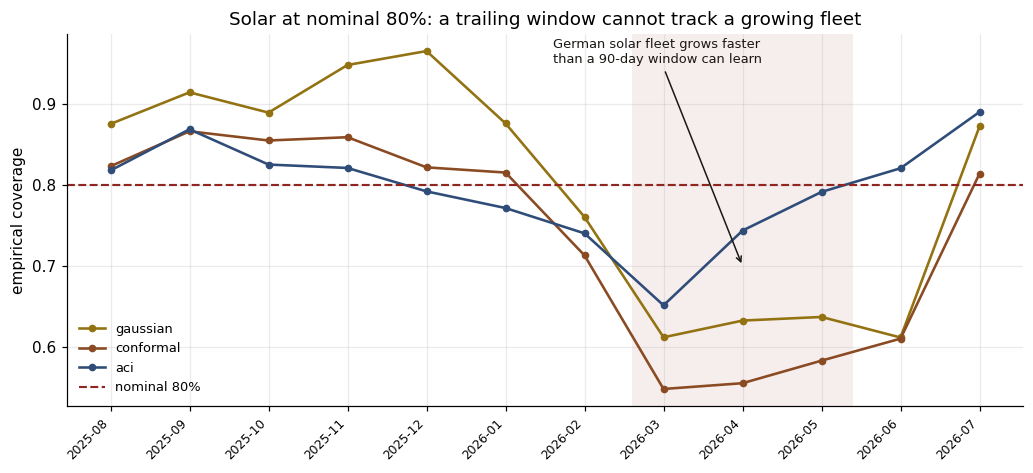

In [29]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.arange(len(solar_monthly))
for method, colour, style in (("gaussian", GOLD, "-"), ("conformal", CLAY, "-"),
                              ("aci", SLATE, "-")):
    ax.plot(x, solar_monthly[method], marker="o", ms=4, lw=1.7, ls=style,
            color=colour, label=method)
ax.axhline(LEVEL_80, color=MADDER, ls="--", lw=1.4, label="nominal 80%")
spring_x = [i for i, m in enumerate(solar_monthly.index) if m in spring]
ax.axvspan(min(spring_x) - 0.4, max(spring_x) + 0.4, color=MADDER, alpha=0.08, lw=0)
ax.annotate("German solar fleet grows faster\nthan a 90-day window can learn",
            xy=(float(np.mean(spring_x)), 0.70), xytext=(5.6, 0.95), fontsize=8.5,
            color=INK, arrowprops={"arrowstyle": "->", "color": INK})
ax.set_xticks(x)
ax.set_xticklabels(solar_monthly.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("empirical coverage")
ax.set_title("Solar at nominal 80%: a trailing window cannot track a growing fleet")
ax.legend(frameon=False, fontsize=8.5, loc="lower left")
plt.tight_layout()
plt.show()

The shaded months are the failure. Both static constructions fall to around 55 to
64% on a band labelled 80%, and they fall together, because they share the
assumption that broke: that the trailing 90 days are drawn from the same
distribution as tomorrow. That exchangeability assumption is precisely what a
growing solar fleet violates, and it is the assumption conformal's finite-sample
guarantee rests on. **Conformal prediction is not a magic word.** Applied
statically under distribution shift it undercovers exactly like the Gaussian it
replaces.

The adaptive line recovers, on a lag — it is a controller, so it has to see the
misses before it can respond to them, and March is where it pays for that.

## 6. Pricing the gap

Miscalibration in a scheduling context is not an abstraction. It is settled in
the imbalance market, and that gives the error a unit.

The Netherlands is the comparison zone here for a mundane reason: NL publishes
imbalance prices on the Transparency Platform and Germany does not. Same
construction as section 3, applied to NL load.

The frame, stated plainly because every clause is an assumption:

- a desk holding a 100 MW portfolio whose errors scale with the system's;
- it reserves flexibility equal to the stated 90% band, and no more;
- for every quarter-hour the outcome escaped that band, the MW beyond the band
  edge is exposure the band said it did not need to carry;
- that excess settles at the **adverse** imbalance spread for the direction it
  went — short of energy pays the shortage price against day-ahead, long of
  energy receives the surplus price against day-ahead;
- favourable spreads are clipped to zero. This counts risk, not profit and loss.

In [30]:
def nl_series(name: str) -> pd.DataFrame:
    """Read one raw NL series back from its monthly parquet chunks."""
    folder = need(f"artifacts/raw_nl/{name}", "python src/pull_data_nl.py")
    parts = [pd.read_parquet(p) for p in sorted(Path(folder).glob("*.parquet"))]
    frame = pd.concat(parts)
    frame.index = pd.DatetimeIndex(frame.index).tz_convert("UTC")
    return frame[~frame.index.duplicated(keep="first")].sort_index()


nl_fc = nl_series("load_forecast").iloc[:, 0]
nl_act = nl_series("load_actual").iloc[:, 0]
nl_imb = nl_series("imbalance_prices")
nl_da = nl_series("day_ahead_prices").iloc[:, 0]

grid = pd.date_range(nl_act.index.min(), nl_act.index.max(), freq="15min", tz="UTC")
nl = pd.DataFrame(index=grid)
nl["load_fc"] = nl_fc.reindex(grid)
nl["load_act"] = nl_act.reindex(grid)
nl["long"] = nl_imb["Long"].reindex(grid)
nl["short"] = nl_imb["Short"].reindex(grid)
nl["da_price"] = nl_da.reindex(grid).ffill(limit=3)
nl = nl.dropna(subset=["load_fc", "load_act", "da_price"])

# Adverse spread: the side of the imbalance settlement that costs money, given
# which way the error went. Clipped at zero on the favourable side.
err_sign = nl["load_act"] - nl["load_fc"]
nl["adverse"] = np.where(
    err_sign > 0,
    np.maximum(nl["short"] - nl["da_price"], 0.0),
    np.maximum(nl["da_price"] - nl["long"], 0.0),
)

print(f"NL panel: {len(nl):,} rows, {nl.index.min()} .. {nl.index.max()}")
print(f"imbalance price coverage: long {nl['long'].notna().mean():.1%}, "
      f"short {nl['short'].notna().mean():.1%}")
print(f"mean NL load: {nl['load_act'].mean():,.0f} MW")
print(f"mean adverse spread over all NL quarter-hours: "
      f"EUR {nl['adverse'].mean():.1f}/MWh")
nl.head(3).round(1)

NL panel: 38,016 rows, 2025-06-30 22:00:00+00:00 .. 2026-07-31 21:45:00+00:00
imbalance price coverage: long 100.0%, short 100.0%
mean NL load: 13,437 MW
mean adverse spread over all NL quarter-hours: EUR 29.8/MWh


,load_fc,load_act,long,short,da_price,adverse
2025-06-30 22:00:00+00:00,10941.9,13191.9,64.8,130.4,111.3,19.1
2025-06-30 22:15:00+00:00,10895.0,13007.8,71.7,144.0,111.3,32.7
2025-06-30 22:30:00+00:00,10859.1,12871.2,63.4,102.3,111.3,0.0


In [31]:
def price_misses(err: pd.DataFrame, lo: pd.DataFrame, hi: pd.DataFrame,
                 adverse: pd.DataFrame, scale: float,
                 hours: float = 0.25) -> tuple[int, float]:
    """Euro cost of the MW that escaped the band. Returns (misses, euros).

    Only the excess beyond the band edge is charged, not the whole error: the
    band's own width is flexibility the desk did in fact reserve. Quarter-hours,
    so MW become MWh at a factor of 0.25.
    """
    scored = lo.notna() & hi.notna() & err.notna()
    missed = scored & ((err < lo) | (err > hi))
    excess = pd.DataFrame(np.where(err > hi, err - hi, lo - err),
                          index=err.index, columns=err.columns)
    euros = float((excess * adverse)[missed].sum().sum() * scale * hours)
    return int(missed.to_numpy().sum()), euros


PORTFOLIO_MW = 100.0
nl_err = error_frame(nl, "load_fc", "load_act", tz="Europe/Amsterdam")
nl_adverse = to_slot_grid(nl["adverse"], tz="Europe/Amsterdam")
scale = PORTFOLIO_MW / nl["load_act"].mean()

g_lo, g_hi = trailing_bands(nl_err, 0.90, "gaussian")
a_lo, a_hi, _ = aci_bands(nl_err, 0.90, gamma=GAMMA)

g_misses, g_eur = price_misses(nl_err, g_lo, g_hi, nl_adverse, scale)
a_misses, a_eur = price_misses(nl_err, a_lo, a_hi, nl_adverse, scale)
_, scored_nl = count_coverage(nl_err, g_lo, g_hi)

avoidable = g_eur - a_eur
nl_cov = count_coverage(nl_err, g_lo, g_hi)
print(f"NL gaussian 90% coverage   : {nl_cov[0] / nl_cov[1]:.4f}  "
      f"(DE-LU load, same construction: "
      f"{at90.loc[('load', 'gaussian'), 'coverage']:.4f})")
print(f"intervals scored           : {scored_nl:,}")
print(f"gaussian 90% band misses   : {g_misses:,} ({g_misses / scored_nl:.1%}) "
      f"-> EUR {g_eur:,.0f}")
print(f"adaptive 90% band misses   : {a_misses:,} ({a_misses / scored_nl:.1%}) "
      f"-> EUR {a_eur:,.0f}")
print(f"avoidable exposure         : EUR {avoidable:,.0f} "
      f"per {PORTFOLIO_MW:.0f} MW over 13 months")

NL gaussian 90% coverage   : 0.8419  (DE-LU load, same construction: 0.8476)
intervals scored           : 32,252
gaussian 90% band misses   : 5,098 (15.8%) -> EUR 362,507
adaptive 90% band misses   : 3,687 (11.4%) -> EUR 158,162
avoidable exposure         : EUR 204,345 per 100 MW over 13 months


### The cross-check against the shipped script

**Slow cell: about 20 seconds.** It is not skipped when its output exists: the
script's numbers are the thing being compared against, so they are recomputed on
every run.

`src/nl_monetize.py` computes the same thing with an explicit day-by-day loop and
a per-interval price lookup. Its logic is entirely inside `main()`, so there is
nothing to import; it is run here as a subprocess — **the second and last one** —
purely to check the vectorised derivation above against it.

The two will not agree bit-for-bit. Pandas computes the trailing standard
deviation with an online update while the script recomputes it from the raw
window each day, and those differ in the last few floating-point places. That
propagates into the band edges and so into the priced excess. The miss *counts*,
which are integers, must match exactly.

In [32]:
proc = subprocess.run([sys.executable, "src/nl_monetize.py"], cwd=ROOT,
                      check=False, capture_output=True, text=True)
if proc.returncode:
    # The script reads the same four raw_nl series the cell above does, so this
    # is a partial pull far more often than it is a bug in the script.
    tail = (proc.stderr or proc.stdout).strip().splitlines()[-3:]
    raise SystemExit(
        f"src/nl_monetize.py exited {proc.returncode}.\n"
        "  It reads artifacts/raw_nl/, the same series as the cell above:\n"
        "    python src/pull_data_nl.py\n"
        "  Its last output was:\n"
        + "".join(f"    {line}\n" for line in tail)
        + "  Full guide: DATA.md"
    )
print(proc.stdout.strip())

numbers = {
    "gauss_eur": r"gaussian 90% band: misses [\d,]+ \([\d.]+%\) -> un-reserved adverse exposure EUR ([\d,]+)",
    "aci_eur": r"adaptive 90% band: misses [\d,]+ \([\d.]+%\) -> EUR ([\d,]+)",
    "gauss_misses": r"gaussian 90% band: misses ([\d,]+)",
    "aci_misses": r"adaptive 90% band: misses ([\d,]+)",
    "scored": r"intervals evaluated: ([\d,]+)",
}
script = {}
for key, pattern in numbers.items():
    match = re.search(pattern, proc.stdout)
    assert match, f"could not parse {key} from nl_monetize.py output"
    script[key] = float(match.group(1).replace(",", ""))

assert int(script["scored"]) == scored_nl, (
    f"script scored {script['scored']:,.0f} intervals, inline scored {scored_nl:,}"
)
assert int(script["gauss_misses"]) == g_misses, (
    f"script counted {script['gauss_misses']:,.0f} gaussian misses, inline {g_misses:,}"
)
assert int(script["aci_misses"]) == a_misses, (
    f"script counted {script['aci_misses']:,.0f} adaptive misses, inline {a_misses:,}"
)
for key, inline_value in (("gauss_eur", g_eur), ("aci_eur", a_eur)):
    rel = abs(inline_value - script[key]) / script[key]
    assert rel < 1e-3, f"{key}: inline EUR {inline_value:,.0f} vs script EUR {script[key]:,.0f}"
    print(f"{key:10s} inline EUR {inline_value:12,.0f}   script EUR {script[key]:12,.0f}   "
          f"relative gap {rel:.2e}")
print("\nmiss counts identical; euro totals agree to under one part in a thousand.")

panel rows: 38,016; imbalance coverage: long 100.0% short 100.0%

intervals evaluated: 32,252
gaussian 90% band: misses 5,098 (15.8%) -> un-reserved adverse exposure EUR 362,500 per 100 MW portfolio / 13 mo
adaptive 90% band: misses 3,687 (11.4%) -> EUR 158,145
mean adverse spread, all intervals: EUR 31.0/MWh; on gaussian-miss intervals: EUR 39.4/MWh
gauss_eur  inline EUR      362,507   script EUR      362,500   relative gap 1.95e-05
aci_eur    inline EUR      158,162   script EUR      158,145   relative gap 1.07e-04

miss counts identical; euro totals agree to under one part in a thousand.


In [33]:
# README headline: "roughly EUR 200,000 per 100 MW of avoidable imbalance exposure".
PUBLISHED_AVOIDABLE_EUR = 200_000.0
assert 0.85 * PUBLISHED_AVOIDABLE_EUR <= avoidable <= 1.15 * PUBLISHED_AVOIDABLE_EUR, (
    f"avoidable exposure is EUR {avoidable:,.0f} per {PORTFOLIO_MW:.0f} MW; "
    f"the article says roughly EUR {PUBLISHED_AVOIDABLE_EUR:,.0f}"
)
print(f"avoidable exposure EUR {avoidable:,.0f} per {PORTFOLIO_MW:.0f} MW over 13 months")
print(f"(article: roughly EUR {PUBLISHED_AVOIDABLE_EUR:,.0f})")
print(f"\nThe gaussian band costs {g_eur / a_eur:.2f}x the adaptive one, on "
      f"{g_misses / a_misses:.2f}x the misses -- so the excess is not only more")
print("frequent, it is more expensive per miss.")

avoidable exposure EUR 204,345 per 100 MW over 13 months
(article: roughly EUR 200,000)

The gaussian band costs 2.29x the adaptive one, on 1.38x the misses -- so the excess is not only more
frequent, it is more expensive per miss.


### And the concentration, which is the actual finding

A total is a number. Where it comes from is the argument. Split the same euro sum
by hour of day.

In [34]:
def exposure_by_hour(err: pd.DataFrame, lo: pd.DataFrame, hi: pd.DataFrame,
                     adverse: pd.DataFrame, scale: float,
                     hours: float = 0.25) -> pd.Series:
    """price_misses, split by hour of day, so the total can be located."""
    scored = lo.notna() & hi.notna() & err.notna()
    missed = scored & ((err < lo) | (err > hi))
    excess = pd.DataFrame(np.where(err > hi, err - hi, lo - err),
                          index=err.index, columns=err.columns)
    euros = (excess * adverse)[missed].fillna(0.0) * scale * hours
    hour = pd.Index(err.columns // 4, name="hour")
    return euros.T.groupby(hour).sum().sum(axis=1)


g_hourly = exposure_by_hour(nl_err, g_lo, g_hi, nl_adverse, scale)
a_hourly = exposure_by_hour(nl_err, a_lo, a_hi, nl_adverse, scale)
exposure = pd.DataFrame({"gaussian": g_hourly, "adaptive": a_hourly,
                         "avoidable": g_hourly - a_hourly})

# The split has to re-add to the total, or it is describing something else.
assert len(exposure) == 24, f"expected 24 hours, got {len(exposure)}"
assert abs(g_hourly.sum() - g_eur) < 1.0, "hourly exposure does not re-add to the total"

top4 = g_hourly.nlargest(4)
share = top4.sum() / g_hourly.sum()
assert share > 4 / 24, (
    f"the four worst hours carry {share:.1%} of the exposure, no more than the "
    f"{4/24:.1%} a flat distribution would give -- the concentration claim fails"
)
print(exposure.round(0).to_string())
print(f"\nfour worst hours {sorted(top4.index.tolist())} carry {share:.1%} of the "
      f"gaussian exposure, against {4/24:.1%} if it were spread evenly")
print(f"euro cost per scored interval, worst hour h{g_hourly.idxmax()}: "
      f"EUR {g_hourly.max() / (scored_nl / 24):.2f}; "
      f"quietest hour h{g_hourly.idxmin()}: EUR {g_hourly.min() / (scored_nl / 24):.2f}")

      gaussian  adaptive  avoidable
hour                               
0      10300.0    7130.0     3169.0
1       9737.0    4174.0     5563.0
2       4276.0    3112.0     1164.0
3       2982.0    2064.0      918.0
4       2598.0    1968.0      630.0
5       4001.0    3002.0      999.0
6       6720.0    4642.0     2078.0
7       6097.0    3406.0     2691.0
8      12475.0    6202.0     6273.0
9      20693.0    9276.0    11417.0
10     26582.0   11181.0    15402.0
11     22674.0    8342.0    14332.0
12     23777.0   12768.0    11009.0
13     18617.0    5792.0    12825.0
14     14730.0    4865.0     9864.0
15     16458.0    6259.0    10199.0
16     29851.0   11548.0    18302.0
17     36170.0   13043.0    23127.0
18     19175.0    5687.0    13488.0
19     12641.0    6164.0     6476.0
20     17344.0   10892.0     6452.0
21     19428.0    3343.0    16084.0
22     12618.0    1924.0    10694.0
23     12564.0   11376.0     1187.0

four worst hours [10, 12, 16, 17] carry 32.1% of the gaussian e

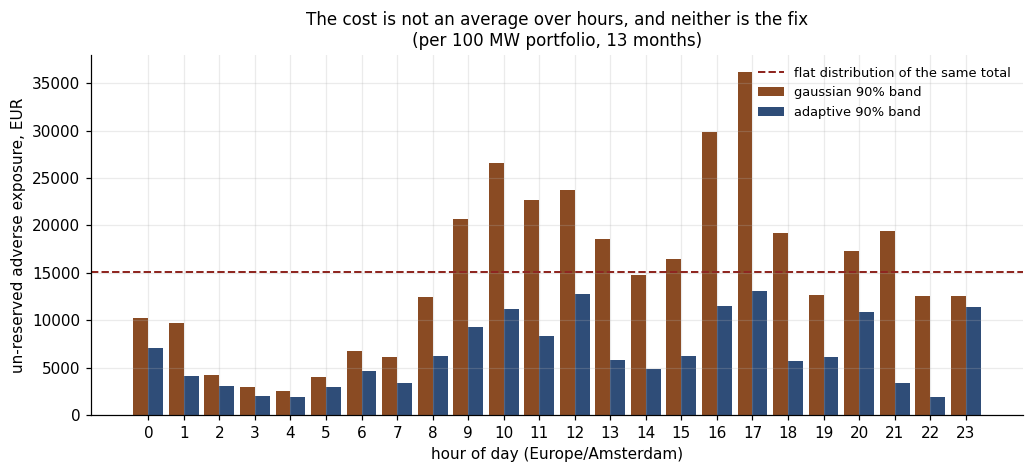

In [35]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
bar_w = 0.42
idx = np.arange(len(exposure))
ax.bar(idx - bar_w / 2, exposure["gaussian"], bar_w, color=CLAY, label="gaussian 90% band")
ax.bar(idx + bar_w / 2, exposure["adaptive"], bar_w, color=SLATE, label="adaptive 90% band")
ax.axhline(g_hourly.sum() / len(exposure), color=MADDER, ls="--", lw=1.3,
           label="flat distribution of the same total")
ax.set_xticks(idx)
ax.set_xticklabels(exposure.index)
ax.set_xlabel("hour of day (Europe/Amsterdam)")
ax.set_ylabel("un-reserved adverse exposure, EUR")
ax.set_title(f"The cost is not an average over hours, and neither is the fix\n"
             f"(per {PORTFOLIO_MW:.0f} MW portfolio, 13 months)", fontsize=11)
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

The dashed line is what the total would look like if miscalibration cost the same
in every hour. It does not. The bars pile up through the late morning and again
at 16:00 to 17:00, and thin out overnight, when neither the error nor the spread
is large. The adaptive band is lower nearly everywhere, and the gap between the
two bars in a given hour is what recalibration is worth in that hour.

That is the whole argument in one picture: **a guarantee that averages over hours
is not a guarantee about money, because money does not average over hours.**

## 7. What this does not support

- **One zone, one window.** DE-LU over 13 months with NL as a single comparison.
  Other bidding zones have different generation mixes and different forecast
  vendors, and nothing here says how those behave.
- **Public system forecasts only.** These are the ENTSO-E published forecasts,
  not whatever proprietary forecast a given trader runs. A desk with a better
  forecast has a different, probably smaller, version of this problem.
- **The euro figure is a model of a cost, not the cost.** It assumes exposure is
  settled at published imbalance prices with no hedging and no portfolio netting.
  It is also computed on the *Dutch* zone throughout — Dutch load errors at Dutch
  imbalance prices — because Germany does not publish imbalance prices on the
  Transparency Platform, so the German failure quantified in sections 3 to 5 is
  not directly priceable here. NL is a stand-in with a comparable calibration
  failure, not a translation of the German one. Treat the number as an order of
  magnitude.
- **Coverage is estimated, not known.** With 13 months of quarter-hours the
  sample is large, but the effective sample is much smaller than the row count
  because adjacent quarter-hours are strongly dependent. Every coverage figure
  here has a wider confidence interval than its four decimal places suggest.
- **The adaptive method's gain was not chosen by the data.** Section 5 sweeps it
  precisely because $\gamma = 0.02$ is a decision, and the sweep shows the
  verdict moving with it. A conclusion that survives only at one gain is not a
  conclusion.

What transfers is the method: **check coverage conditionally, not marginally, and
check it where the decision is expensive rather than on average.**

### The check worth stealing

Take the interval your desk actually quotes, split its hit rate by hour of day,
and overlay the price curve. It is one `groupby` on data you already have, and it
either shows you a flat line or it shows you section 4.

### Where the code lives

| Step | Module | In this notebook |
|---|---|---|
| ENTSO-E pulls | `src/pull_data.py`, `src/pull_data_nl.py` | run as a subprocess: slow I/O |
| Panel assembly | `src/assemble.py` | run as a subprocess with the pulls |
| Band construction | `src/calibration.py` | reimplemented inline (`trailing_bands`), checked against the artifact |
| Coverage and conditional bias | `src/calibration.py` | reimplemented inline (`count_coverage`), checked against the artifact |
| Adaptive conformal inference | `src/aci.py` | reimplemented inline (`aci_bands`), checked against the artifact |
| Coverage by month | `src/monthly_coverage.py` | reimplemented inline (`coverage_by_month`), checked against the artifact |
| Imbalance monetisation | `src/nl_monetize.py` | reimplemented inline (`price_misses`), checked by running the script |